In [14]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
import joblib

REPO_ROOT = Path.cwd().parent.parent
BACKEND_DIR = REPO_ROOT / "backend"
sys.path.insert(0, str(BACKEND_DIR))
sys.path.insert(0, str(Path.cwd()))

from _pool_common import (
    load_pool_data,
    compute_metrics_averaged_over_windows,
    metrics_to_parquet,
    TEST_SIZE,
    FORECAST_HORIZON,
    ROLLING_STEP,
    MIN_TRAIN_STACK,
    ARTIFACTS_DIR,
    TEST_TICKERS,
)

LAG_RETURNS = 5
RSI_PERIOD = 14
MACD_FAST, MACD_SLOW, MACD_SIGNAL = 12, 26, 9
XGB_PARAMS = dict(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)


def fetch_cnn_fear_greed_index(limit_days=500):
    try:
        import urllib.request
        import json
        url = f"https://api.alternative.me/fng/?limit={limit_days}"
        with urllib.request.urlopen(url, timeout=10) as resp:
            data = json.load(resp)
        rows = []
        for d in data.get("data", []):
            ts = pd.to_datetime(int(d["timestamp"]), unit="s").normalize()
            rows.append({"timestamp": ts, "fear_greed": float(d.get("value", np.nan))})
        if not rows:
            return pd.DataFrame(columns=["timestamp", "fear_greed"])
        return pd.DataFrame(rows).drop_duplicates("timestamp").sort_values("timestamp")
    except Exception as e:
        print(f"Fear & Greed fetch failed ({e}), using NaN.")
        return pd.DataFrame(columns=["timestamp", "fear_greed"])

In [15]:
def _rsi(series: pd.Series, period: int) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False).mean()
    rs = avg_gain / np.where(avg_loss != 0, avg_loss, 1e-10)
    return 100 - (100 / (1 + rs))


def build_feature_df(grp: pd.DataFrame):
    """Same as stack: XGB features = VIX, cyclical month, fear_greed. Target = next 21 returns."""
    df = grp.sort_values("timestamp").copy()
    df["close"] = df["close"].astype(float)
    df["return"] = df["close"].pct_change()
    for i in range(1, LAG_RETURNS + 1):
        df[f"ret_lag_{i}"] = df["return"].shift(i)
    if "volume" in df.columns:
        df["volume_lag_1"] = df["volume"].astype(float).shift(1)
    else:
        df["volume_lag_1"] = np.nan
    df["rsi"] = _rsi(df["close"], RSI_PERIOD)
    ema_fast = df["close"].ewm(span=MACD_FAST, adjust=False).mean()
    ema_slow = df["close"].ewm(span=MACD_SLOW, adjust=False).mean()
    df["macd_line"] = ema_fast - ema_slow
    df["macd_signal"] = df["macd_line"].ewm(span=MACD_SIGNAL, adjust=False).mean()
    if "vix" in df.columns:
        df["vix_lag_1"] = df["vix"].astype(float).shift(1)
    else:
        df["vix_lag_1"] = np.nan
    df["month"] = pd.to_datetime(df["timestamp"]).dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    if "fear_greed" not in df.columns:
        df["fear_greed"] = 50.0
    else:
        df["fear_greed"] = df["fear_greed"].fillna(50.0)
    for h in range(1, FORECAST_HORIZON + 1):
        df[f"target_{h}"] = df["return"].shift(-h)
    feature_cols_lstm = [f"ret_lag_{i}" for i in range(1, LAG_RETURNS + 1)] + [
        "volume_lag_1", "rsi", "macd_line", "macd_signal"
    ]
    feature_cols_xgb = ["vix_lag_1", "month_sin", "month_cos", "fear_greed"]
    target_cols = [f"target_{h}" for h in range(1, FORECAST_HORIZON + 1)]
    base_cols = ["timestamp", "close", "return"] + feature_cols_lstm + feature_cols_xgb + target_cols
    out = df[[c for c in base_cols if c in df.columns]].copy()
    return out.dropna(), feature_cols_lstm, feature_cols_xgb, target_cols


def get_forecast_xgb(context_df: pd.DataFrame, horizon: int) -> list:
    """XGBoost only: train on context, predict 21 returns, convert to prices. Same features as stack (VIX, month, fear_greed)."""
    try:
        feat_df, _, feature_cols_xgb, target_cols = build_feature_df(context_df)
    except Exception:
        return []
    if len(feat_df) < MIN_TRAIN_STACK + horizon:
        return []
    X_xgb = feat_df[feature_cols_xgb].values.astype(np.float32)
    y = feat_df[target_cols].values.astype(np.float32)
    n = len(y)
    train_end = n - horizon
    X_train, y_train = X_xgb[:train_end], y[:train_end]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_full_s = scaler.transform(X_xgb)
    xgb = XGBRegressor(**XGB_PARAMS)
    xgb_multi = MultiOutputRegressor(xgb)
    xgb_multi.fit(X_train_s, y_train)
    last_idx = n - 1
    last_row = X_full_s[last_idx : last_idx + 1]
    xgb_21 = xgb_multi.predict(last_row).ravel()
    final_returns = np.asarray(xgb_21)
    p0 = float(context_df["close"].iloc[-1])
    prices = p0 * np.cumprod(np.concatenate([[1.0], 1.0 + final_returns]))[1:]
    return [float(p) for p in prices[:horizon]]

In [16]:
stacked = load_pool_data(with_vix=True, with_volume=True)
fear_greed_df = fetch_cnn_fear_greed_index(limit_days=1500)
if not fear_greed_df.empty:
    stacked["date"] = pd.to_datetime(stacked["timestamp"]).dt.normalize()
    fear_greed_df["date"] = fear_greed_df["timestamp"]
    stacked = stacked.merge(fear_greed_df[["date", "fear_greed"]], on="date", how="left")
    stacked["fear_greed"] = stacked["fear_greed"].ffill().bfill()
    stacked = stacked.drop(columns=["date"])
print(stacked.groupby("symbol").size())
stacked.head(10)

symbol
AAPL    1255
JNJ     1255
JPM     1255
MSFT    1255
SPY     1255
WMT     1255
dtype: int64


,timestamp,symbol,close,volume,vix,fear_greed
0,2021-03-05,AAPL,121.419998,153766600,24.660000,77.0
1,2021-03-08,AAPL,116.360001,154376600,25.469999,81.0
2,2021-03-09,AAPL,121.089996,129525800,24.030001,81.0
3,2021-03-10,AAPL,119.980003,111943300,22.559999,68.0
4,2021-03-11,AAPL,121.959999,103026500,21.910000,73.0
5,2021-03-12,AAPL,121.029999,88105100,20.690001,70.0
6,2021-03-15,AAPL,123.989998,92403800,20.030001,76.0
7,2021-03-16,AAPL,125.570000,115227900,19.790001,71.0
8,2021-03-17,AAPL,124.760002,111932600,19.230000,71.0
9,2021-03-18,AAPL,120.529999,121229700,21.580000,72.0


In [17]:
model_name = "xgboost"
all_preds = []
for sym in TEST_TICKERS:
    grp = stacked[stacked["symbol"] == sym].copy()
    if grp.empty:
        continue
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    prices = grp.set_index("timestamp")["close"].astype(float).dropna()
    n = len(prices)
    if n < TEST_SIZE + MIN_TRAIN_STACK:
        continue
    split_idx = n - TEST_SIZE
    test_index = prices.index[split_idx:]
    test_values = prices.values[split_idx:]
    preds = []
    window_ix = 0
    start = 0
    while start + FORECAST_HORIZON <= TEST_SIZE:
        context_cols = ["timestamp", "close", "vix"] + [c for c in ["volume", "fear_greed"] if c in grp.columns]
        context_df = grp.iloc[: split_idx + start][context_cols].copy()
        if len(context_df) < MIN_TRAIN_STACK:
            start += ROLLING_STEP
            continue
        price_list = get_forecast_xgb(context_df, FORECAST_HORIZON)
        if not price_list or len(price_list) < FORECAST_HORIZON:
            start += ROLLING_STEP
            window_ix += 1
            continue
        for h in range(FORECAST_HORIZON):
            idx = start + h
            ts = test_index[idx]
            y_true = float(test_values[idx])
            y_pred = float(price_list[h])
            preds.append({"timestamp": ts, "y_true": y_true, "y_pred": y_pred, "window_ix": window_ix})
        window_ix += 1
        start += ROLLING_STEP
    if preds:
        pred_df = pd.DataFrame(preds)
        pred_df["symbol"] = sym
        all_preds.append(pred_df)

pred_xgb = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame(
    columns=["timestamp", "y_true", "y_pred", "window_ix", "symbol"]
)
print(pred_xgb.groupby("symbol").size() if not pred_xgb.empty else "No predictions.")
pred_xgb.head()

symbol
MSFT    126
SPY     126
dtype: int64


,timestamp,y_true,y_pred,window_ix,symbol
0,2025-12-05,483.160004,480.141459,0,MSFT
1,2025-12-08,491.019989,478.582457,0,MSFT
2,2025-12-09,492.019989,478.954319,0,MSFT
3,2025-12-10,478.559998,478.619680,0,MSFT
4,2025-12-11,483.470001,478.687120,0,MSFT


In [18]:
metrics_rows = []
for sym in pred_xgb["symbol"].unique():
    sub = pred_xgb[pred_xgb["symbol"] == sym]
    m = compute_metrics_averaged_over_windows(sub)
    metrics_rows.append({"model": model_name, "symbol": sym, **m})
m_overall = compute_metrics_averaged_over_windows(pred_xgb)
metrics_rows.append({"model": model_name, "symbol": "overall", **m_overall})

metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string())
metrics_to_parquet(metrics_rows, ARTIFACTS_DIR / "metrics_xgboost_pool.parquet")
print("Saved:", ARTIFACTS_DIR / "metrics_xgboost_pool.parquet")

     model   symbol        MAE       RMSE    MAPE_%
0  xgboost     MSFT  25.407595  29.421197  6.003430
1  xgboost      SPY   5.786751   7.178622  0.841863
2  xgboost  overall  15.597173  21.991616  3.422647
Saved: C:\capstone_project_unfc\model\experiments-pool\artifacts\metrics_xgboost_pool.parquet


XGBoost feature importance (avg over 21 horizons):
   feature  importance
 vix_lag_1    0.277165
 month_sin    0.274475
fear_greed    0.230713
 month_cos    0.217647


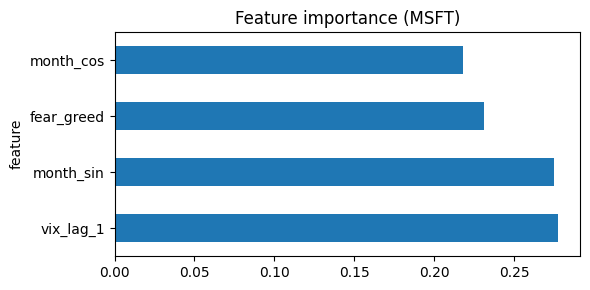

In [19]:
# Feature importance (average across 21 horizon-specific XGB estimators, fitted on first test symbol)
import matplotlib.pyplot as plt
sym = TEST_TICKERS[0]
grp = stacked[stacked["symbol"] == sym].sort_values("timestamp").reset_index(drop=True)
feat_df, _, feature_cols_xgb, target_cols = build_feature_df(grp)
if len(feat_df) >= MIN_TRAIN_STACK + FORECAST_HORIZON:
    X = feat_df[feature_cols_xgb].values.astype(np.float32)
    y = feat_df[target_cols].values.astype(np.float32)
    n = len(y)
    train_end = n - FORECAST_HORIZON
    X_train_s = StandardScaler().fit_transform(X[:train_end])
    y_train = y[:train_end]
    xgb_multi = MultiOutputRegressor(XGBRegressor(**XGB_PARAMS))
    xgb_multi.fit(X_train_s, y_train)
    imp = np.mean([est.feature_importances_ for est in xgb_multi.estimators_], axis=0)
    fi_df = pd.DataFrame({"feature": feature_cols_xgb, "importance": imp}).sort_values("importance", ascending=False)
    print("XGBoost feature importance (avg over 21 horizons):")
    print(fi_df.to_string(index=False))
    fi_df.plot(x="feature", y="importance", kind="barh", legend=False, figsize=(6, 3))
    plt.title(f"Feature importance ({sym})")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for feature importance.")

In [20]:
# Save XGBoost model as artifact (model + scaler + feature names for inference)
ARTIFACT_PATH = ARTIFACTS_DIR / "xgboost_pool.joblib"
sym = TEST_TICKERS[0]
grp = stacked[stacked["symbol"] == sym].sort_values("timestamp").reset_index(drop=True)
feat_df, _, feature_cols_xgb, target_cols = build_feature_df(grp)
if len(feat_df) >= MIN_TRAIN_STACK + FORECAST_HORIZON:
    X = feat_df[feature_cols_xgb].values.astype(np.float32)
    y = feat_df[target_cols].values.astype(np.float32)
    n = len(y)
    train_end = n - FORECAST_HORIZON
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X[:train_end])
    y_train = y[:train_end]
    xgb_multi = MultiOutputRegressor(XGBRegressor(**XGB_PARAMS))
    xgb_multi.fit(X_train_s, y_train)
    artifact = {
        "model": xgb_multi,
        "scaler": scaler,
        "feature_cols_xgb": feature_cols_xgb,
        "FORECAST_HORIZON": FORECAST_HORIZON,
        "XGB_PARAMS": XGB_PARAMS,
    }
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(artifact, ARTIFACT_PATH)
    print("Saved artifact:", ARTIFACT_PATH)
else:
    print("Not enough data to save artifact.")

Saved artifact: C:\capstone_project_unfc\model\experiments-pool\artifacts\xgboost_pool.joblib
